In [12]:
!pip install --upgrade  langchain langchain-google-genai "langchain[docarray]" faiss-cpu pypdf langchain_community langchain_openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.4/55.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 415.4/415.4 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 44.8 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.41
    Uninstalling langchain-core-0.3.41:
      Successfully uninstalled langchain-core-0.3.41


In [9]:
import os
import requests
from google.colab import userdata
from PIL import Image

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, Markdown

In [40]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_community.vectorstores import DocArrayInMemorySearch
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.embeddings import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain.schema.runnable import RunnablePassthrough, RunnableLambda

In [14]:
from langchain.schema.document import Document
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import CharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_openai import ChatOpenAI

In [10]:
OPENAI_API_TOKEN=userdata.get('OPENAI_API_KEY')
os.environ["OPENAI_API_KEY"] = OPENAI_API_TOKEN

In [15]:
model = ChatOpenAI(model="gpt-4o-mini")

In [17]:
model.invoke("Tell me a joke!")

AIMessage(content='Why don’t scientists trust atoms?\n\nBecause they make up everything!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 12, 'total_tokens': 26, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_06737a9306', 'finish_reason': 'stop', 'logprobs': None}, id='run-d260747c-b726-40a7-9a7d-a9c3c80bc7f3-0', usage_metadata={'input_tokens': 12, 'output_tokens': 14, 'total_tokens': 26, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [18]:
model.invoke("Tell me a joke!").content

'Why did the scarecrow win an award? \n\nBecause he was outstanding in his field!'

In [19]:
model(
    [
        HumanMessage(content="Tell me a joke!")
    ]
).content

<ipython-input-19-636f2a549150>:1: LangChainDeprecationWarning: The method `BaseChatModel.__call__` was deprecated in langchain-core 0.1.7 and will be removed in 1.0. Use :meth:`~invoke` instead.
  model(


'Why did the scarecrow win an award? \n\nBecause he was outstanding in his field!'

In [26]:
def get_image(url,filename,extension):
  content = requests.get(url).content
  with open(f'/content/{filename}.{extension}', 'wb') as f:
    f.write(content)
  image = Image.open(f"/content/{filename}.{extension}")
  image.show()
  return image, url

image, image_url = get_image("https://static.nike.com/a/images/t_PDP_1728_v1/f_auto,q_auto:eco/1705ca64-fbc8-4b79-a451-4ab77760c219/dunk-low-older-shoes-C7T1cx.png",
                  "nike-shoes",
                  "png")

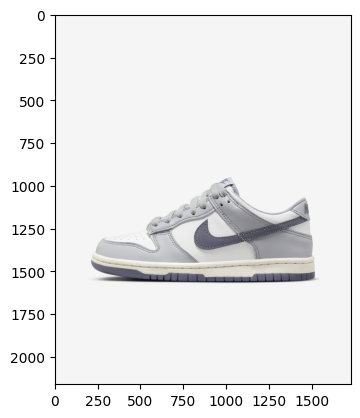

In [22]:
plt.imshow(image)
plt.show()

In [27]:
message = HumanMessage(
    content=[
        {
            "type": "image_url",
            "image_url": {
                "url": image_url
            }
        }
    ]
)

In [28]:
model.invoke([message]).content

'These are Nike Dunk Low sneakers featuring a combination of white, gray, and navy colors. The design includes a classic low-top silhouette with perforations for ventilation on the toe box and a prominent Nike Swoosh on the side. The shoe has a textured upper likely made from leather or synthetic materials, giving it a sleek look. The contrasting colors make it a stylish option for both casual and sporty outfits.'

In [30]:
prompt = "Give me a cool name of the image."

In [31]:
message = HumanMessage(
    content=[
        {
            "type": "text",
            "text": prompt
        },
        {
            "type": "image_url",
            "image_url": {
                "url": image_url
            }
        }
    ]
)

In [32]:
model.invoke([message]).content

'**"Slate Dream"**'

In [33]:
loader = TextLoader("/content/nike_shoes.txt")
print(loader.load()[0].page_content)

store_information = """

Nike Air Max Plus sneakers. They feature a brown upper with a black Nike Swoosh logo on the side and a visible Air Max unit in the heel. The sole is white.
Here are some more details about the Nike Air Max Plus:
Style: TN
Release date: January 1, 2017
Style code: 852630-300
Original retail price: $150 USD
The Air Max Plus, also known as the TN, is a popular Nike running shoe that was first released in 1998. It is known for its unique design, which includes a gradient upper, visible Air Max units, and a wavy outsole. The TN has been a popular shoe among sneakerheads and casual wearers alike for over two decades.
It features a brown upper with a black Swoosh logo and a white sole. The shoe is currently available for resale on the StockX marketplace for an average price of around $150 USD.
Nike Air Max Plus Store Location: "Kings Way, Kathmandu, Nepal".
\n\n\n



Nike Dunk Low Retro sneakers.
Here are some more details about the Nike Dunk Low Retro:
Style: Low-top

In [34]:
def get_text_chunks_langchain(text):
  text_splitter = CharacterTextSplitter(chunk_size=20, chunk_overlap=10)
  docs = [Document(page_content=x) for x in text_splitter.split_text(text)]
  return docs

In [35]:
text = loader.load()[0].page_content
docs = get_text_chunks_langchain(text)

In [37]:
embeddings = OpenAIEmbeddings()

<ipython-input-37-73ad2f8e367a>:1: LangChainDeprecationWarning: The class `OpenAIEmbeddings` was deprecated in LangChain 0.0.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import OpenAIEmbeddings``.
  embeddings = OpenAIEmbeddings()


In [38]:
vectorstore = FAISS.from_documents(docs, embeddings)

In [39]:
retriever = vectorstore.as_retriever()

In [41]:
template = """
```
{context}
```

{query}


Provide brief information and store location.
"""

In [42]:
prompt = ChatPromptTemplate.from_template(template)

In [44]:
rag_chain = (
    {"context": retriever, "query": RunnablePassthrough()}
    | prompt
    | model
    | StrOutputParser()
)

In [45]:
result = rag_chain.invoke("can you give me a detail of nike sandal?")

In [46]:
display(Markdown(result))

The Nike sandal is identified as the Nike Slide/Sandal, which is a unisex option known for its comfort and support. Key features include a soft, one-piece upper made of synthetic material, a Phylon midsole for cushioning, and a rubber outsole for traction and durability. The sandal prominently displays the Nike Swoosh logo on the strap and comes in various colors, including black, white, and beige.

**Store Location:** Bhaktapur, Nepal.